## Imports

In [237]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


#### Load and check data

In [238]:
# Load the training and test data
X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
X_test = pd.read_csv('Datasets/cleaned_X_test2.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
y_test = pd.read_csv('Datasets/y_test.csv')


In [239]:
# Ensure the test data has the same columns as the training data
X_test = X_test[X_train.columns]
y_test = y_test[y_train.columns] 

In [240]:
# check the shape of the data
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# check collumn names are identical
print("X_train columns:", X_train.columns.tolist())
print("X_test columns:", X_test.columns.tolist())


y_train = y_train.values.squeeze()  # Flatten if a single column DataFrame
y_test = y_test.values.squeeze()

print(y_train)


Shape of X_train: (404, 516)
Shape of y_train: (404, 10)
Shape of y_test: (101, 10)
X_train columns: ['Robert Duncan McNeill', 'Than Wyenn', 'duration', 'Marvin Petal', 'David Wise', 'Tracy Tormé', 'Richard Long', 'James Best', 'Anthony Wilson', 'Eric Kaplan', 'Patrick R. Norris', 'Gabrielle Beaumont', 'Robert Walker Jr.', 'Patrick O&apos;Neal', 'Robert Lewin', 'Tod Andrews', 'Phyllis Love', 'John D.F. Black', 'John McGiver', 'Earl Hamner Jr.', 'John Larch', 'Cirroc Lofton', 'Harold D. Schuster', 'Howard Smith', 'Douglas Heyes', 'Timothy Bond', 'Katharyn Powers', 'Shari Goodhartz', 'Romance', 'Rich Moore', 'David Greene', 'Jeffrey Hunter', 'Christine White', 'Don Mankiewicz', 'Guy Wilkerson', 'Barry Nelson', 'Crystal Chesney', 'Katey Sagal', 'Linden Chiles', 'Animation', 'David Straiton', 'Richard Matheson', 'Frederick Louis Fox', 'Montgomery Pittman', 'Bernard Girard', 'Stephen L. Posey', 'Robert Sampson', 'Frank Aletter', 'Nancy Kulp', 'Elliot Silverstein', 'Robert Wiemer', 'Terry Wi

In [241]:
# check if there are missing values or collumns
train_columns = set(X_train.columns)
test_columns = set(X_test.columns)

missing_in_test = train_columns - test_columns
extra_in_test = test_columns - train_columns

print("Missing in X_test:", missing_in_test)
print("Extra in X_test:", extra_in_test)


Missing in X_test: set()
Extra in X_test: set()


## Initialize and train the decision tree

In [242]:
# Initialize the classifier
dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=60) # choose entropy as the data set is smaller

# Train the classifier
dt_classifier.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=60)

## predict

In [243]:
# Predict on test data
y_pred = dt_classifier.predict(X_test)

In [254]:
print("Shape of y_test:", y_test.shape)
print("Shape of y_pred:", y_pred.shape)
assert y_test.shape == y_pred.shape, "Shapes of y_test and y_pred must match."


Shape of y_test: (101, 10)
Shape of y_pred: (101, 10)


## Evaluate model

In [245]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.12
Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.38      0.26         8
           1       0.17      0.09      0.12        11
           2       0.11      0.06      0.08        16
           3       0.25      0.13      0.17        15
           4       0.40      0.18      0.25        11
           5       0.06      0.14      0.08         7
           6       0.20      0.24      0.22        17
           7       0.08      0.08      0.08        12
           8       0.50      0.33      0.40        18
           9       0.14      0.18      0.16        11

   micro avg       0.19      0.18      0.19       126
   macro avg       0.21      0.18      0.18       126
weighted avg       0.23      0.18      0.19       126
 samples avg       0.19      0.20      0.19       126



## Visualize tree

In [246]:
tree_rules = export_text(dt_classifier, feature_names=list(X_train.columns))
print(tree_rules)


|--- year <= 1966.50
|   |--- IMDb rating <= 0.74
|   |   |--- year <= 1962.50
|   |   |   |--- Douglas Heyes <= 0.50
|   |   |   |   |--- Robert Florey <= 0.50
|   |   |   |   |   |--- month <= 5.00
|   |   |   |   |   |   |--- Allen H. Miner <= 0.50
|   |   |   |   |   |   |   |--- Richard L. Bare <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Richard L. Bare >  0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Allen H. Miner >  0.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- month >  5.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Robert Florey >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Douglas Heyes >  0.50
|   |   |   |   |--- Thomas Gomez <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Thomas Gomez >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- year >  1962.50
|   |   |   |--- IMDb description <= 0.00
|   |   |   |   |--- Richard Don

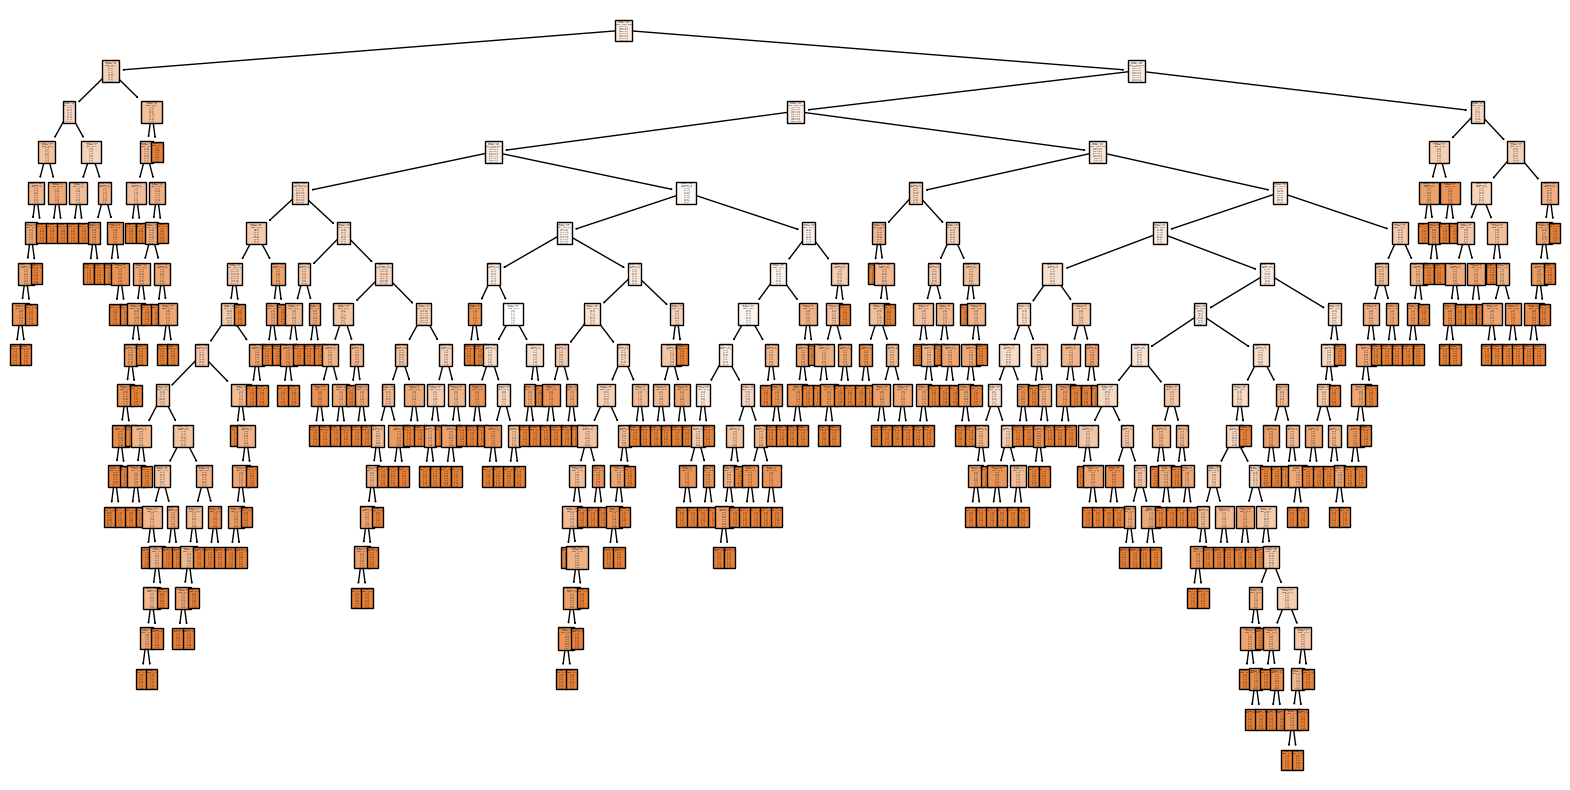

In [247]:
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, feature_names=X_train.columns, class_names=dt_classifier.classes_, filled=True)
plt.show()


## Optimize training/Finetuning the decision tree

**Hyperparameter Tuning**: Use techniques like grid search (GridSearchCV) or random search (RandomizedSearchCV) to find optimal parameters for your decision tree. 

**Overfitting Prevention**: Adjust parameters like max_depth, min_samples_split, and min_samples_leaf to prevent overfitting.


### Gridsearch

In [248]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [1, 5, 4],
    'min_samples_leaf': [1, 3, 4],
    'criterion': ['gini', 'entropy']
}


In [249]:
# Initialize the model
dt_classifier = DecisionTreeClassifier(random_state=33)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=1; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=1; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1

/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 436, in _validate_par

In [250]:
# Use the best hyperparameters to initialize a new model
best_dt_classifier = DecisionTreeClassifier(**best_params, random_state=42)

# Fit the model on the training data
best_dt_classifier.fit(X_train, y_train)

# Evaluate on the test data
y_pred = best_dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")

Test Set Accuracy: 0.09


### Randomized Search

In [251]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Randomized parameter grid
random_grid = {
    'max_depth': [None] + list(np.arange(3, 15)),
    'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 5),
    'criterion': ['gini', 'entropy']
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=dt_classifier, param_distributions=random_grid, n_iter=50, cv=5, scoring='accuracy', verbose=2, random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the data
random_search.fit(X_train, y_train)

# Get the best parameters
best_params = random_search.best_params_
print("\n Best Hyperparameters:", best_params)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=14, min_samples_leaf=3, min_samples_split=5; total time=   0.0s
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=14, min_samples_leaf=3, min_samples_split=5; total time=   0.0s
[CV] END criterion=entropy, max_depth=14, min_samples_leaf=3, min_samples_split=5; total time=   0.0s
[CV] END criterion=entropy, max_depth=14, min_samples_leaf=3, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, 

In [252]:
# Use the best hyperparameters to initialize a new model
best_dt_classifier = DecisionTreeClassifier(**best_params, random_state=42)

# Fit the model on the training data
best_dt_classifier.fit(X_train, y_train)

# Evaluate on the test data
y_pred = best_dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")


Test Set Accuracy: 0.10
